## AI for finance [IE 412]

#### Hands-on Practice on Session #1
#### [Session 1] Interest risk modeling via PCA(Principal component analysis) + Clustering
##### Main assistant for this Session: Suhwan Park (suhwan@unist.ac.kr), Sangjin Jin (sj.jin@unist.ac.kr)


1. Introduction to PCA
2. Data
3. Visualization of Yield curve
4. PCA applied to finance by using US DATA
    - 4.1. PCA Using Sklearn package
    - 4.2. What is Level, Slope and Curvature?
    - 4.3. Correlation coefficient between PCA and original value
    - 4.4. PCA Analysis [HW 1]
5. PCA applied to finance by using Korean DATA [HW 2]
6. Market regime analysis via Clustering [HW 3]
7. [advanced] Autoencoder
    - 7.1. Linear Autoencoder

### 1. Introduction to PCA

![img](https://drive.google.com/uc?id=1xWE6wD65Pv9NPtkutH2TbE6y_ibdvJYE)
- PCA is the bedrock dimensionality reduction technique for probability and statistics.
- It’s still commonly used in machine learning applications when you have big data that might have some statistical distribution and you want to uncover the low dimensional patterns to build models.


### 2. Data


- in this chapter, we use the daily treasury par yield curve rate in U.S. department of the treasury.
- If you are interested in python crawling, you can easily collect data using beautifulsoup package.

In [107]:
import numpy as np
import pandas as pd
import requests
import datetime
import os
from bs4 import BeautifulSoup

In [108]:
US_bond_data  = pd.read_csv('/US_bond_data_26Spr.csv')

In [109]:
US_bond_data

,Date,1 Mo,2 Mo,3 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
0,2009-01-02,0.04,0.06,0.08,0.28,0.40,0.88,1.14,1.72,2.07,2.46,3.22,2.83
1,2009-01-05,0.05,0.10,0.14,0.32,0.43,0.78,1.08,1.67,2.07,2.49,3.37,3.00
2,2009-01-06,0.05,0.10,0.14,0.31,0.45,0.80,1.10,1.68,2.07,2.51,3.41,3.04
3,2009-01-07,0.03,0.07,0.11,0.29,0.44,0.82,1.15,1.66,2.02,2.52,3.41,3.05
4,2009-01-08,0.04,0.06,0.09,0.28,0.44,0.83,1.16,1.60,1.95,2.47,3.40,3.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4246,2025-12-24,3.72,3.74,3.69,3.59,3.50,3.47,3.56,3.70,3.91,4.15,4.75,4.79
4247,2025-12-26,3.70,3.72,3.64,3.58,3.49,3.46,3.54,3.68,3.89,4.14,4.76,4.81
4248,2025-12-29,3.69,3.70,3.68,3.59,3.48,3.45,3.51,3.67,3.88,4.12,4.75,4.80
4249,2025-12-30,3.65,3.65,3.65,3.59,3.47,3.45,3.50,3.68,3.89,4.14,4.76,4.81


### 3. Visualization of Yield curve

- Yield curve represent several interest rates across different maturities.

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

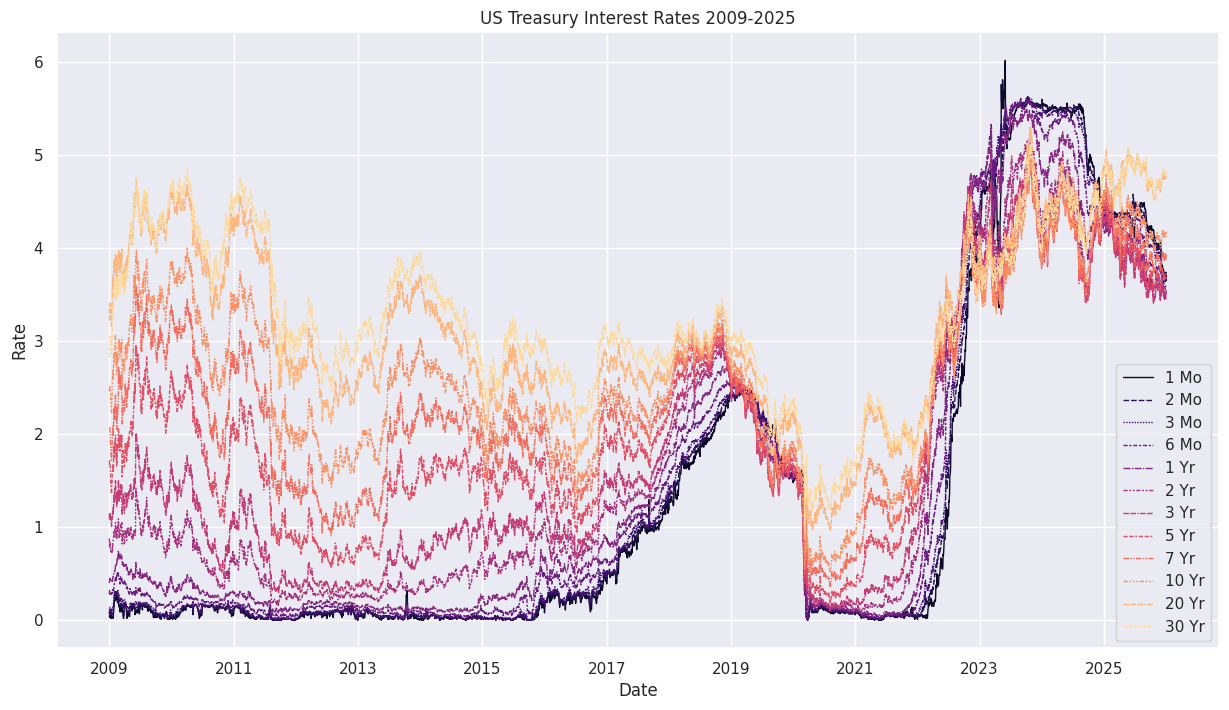

In [111]:
sns.set_theme(style="whitegrid")
sns.set(rc = {'figure.figsize':(15,8)})
sns.lineplot(data=US_bond_data,  linewidth=1.0, palette = "magma")
plt.xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
plt.title("US Treasury Interest Rates 2009-2025")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.savefig("Figure_1.png")
plt.show()

### 4. PCA applied to finance by using US data

* Principal Component Analysis (PCA) quantifies movements in a specific market. Consider bonds with different maturities. Changes in the yield curve do not move randomly, but are influenced by specific rules. for example, investors often refer to movements in the yield curve in  terms of three driving factors: **level**, **slope**, and **curvature**. PCA formalizes this viewpoint and allows us to evaluate when a sector of the yield curve has cheapened or richened beyond that prescribed by recent yield movements.

- the first principal component records an almost parallel shift of the yield curve
- the second one a change in the slope (tilt)
- the third one a change located in the middle of the term structure (curvature or convexity).


- PC1(Level)
- PC2(Slope)
- PC3(Curvature)

### 4-1. PCA Using Sklearn package

- Sklearn Link : https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [112]:
from sklearn.decomposition import PCA     # import PCA package

def PCA_analysis(data, norm = False, n_pcs = 10):
    rate_dataset = data.iloc[:, 1:].copy()   # Exclude date columns

    if norm == True:
        rate_dataset -= rate_dataset.mean(axis=0)
    else:
        pass

    pca = PCA(n_components=n_pcs, svd_solver = "auto", random_state = 2022)
    pcs_overtime = pca.fit_transform(rate_dataset)
    pcs_overtime_df = pd.DataFrame(data=pcs_overtime)

    pcs_shape_df = pd.DataFrame(pca.components_).T

    print('explained variance ratio :', pca.explained_variance_ratio_.cumsum()[0:3])

    return pcs_shape_df, pcs_overtime_df

In [113]:
pc_shape, pc_overtime = PCA_analysis(US_bond_data, norm = True, n_pcs= 10)

explained variance ratio : [0.90992768 0.98578555 0.99786658]


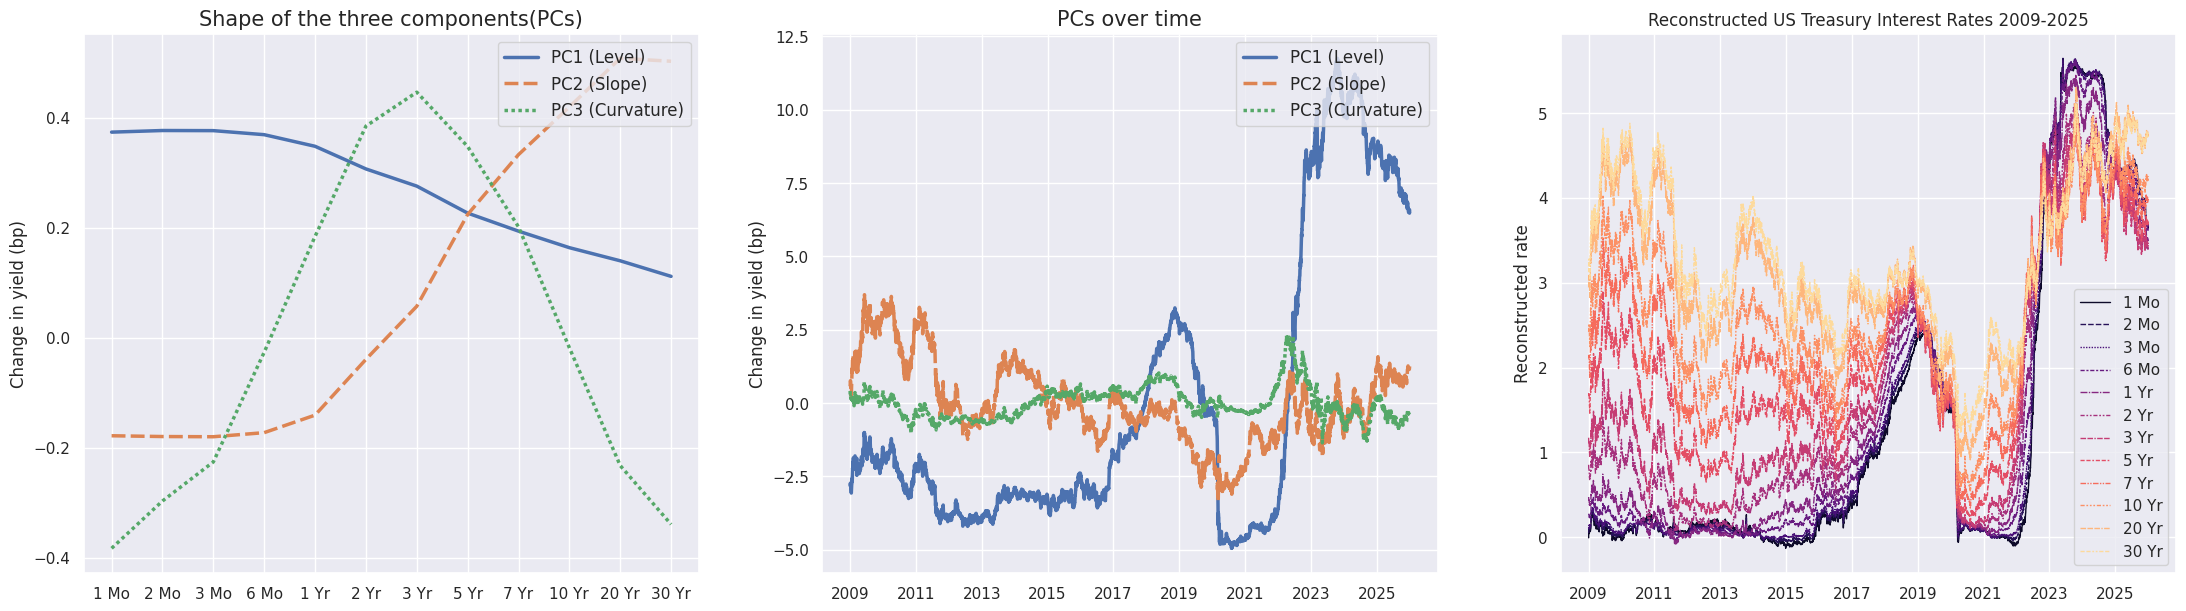

In [114]:
fig, axes = plt.subplots(1, 3, figsize=(27,7))

# PCs over maturity
pc3_comp = pc_shape.iloc[:, :3]
pc3_comp.columns = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
sns.lineplot(data=pc3_comp,  linewidth=2.5, ax = axes[0])
axes[0].set_title("Shape of the three components(PCs)", fontsize = 15)
axes[0].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[0].set_xticks([0,1,2,3,4,5,6,7,8,9,10,11],['1 Mo', '2 Mo', '3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr',  '10 Yr', '20 Yr', '30 Yr'])
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, loc='upper right', fontsize=12)


# PCs over time
pc3_time = pc_overtime.iloc[:, :3]
pc3_time.columns = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
sns.lineplot(data=pc3_time,  linewidth=2.5, ax = axes[1])
axes[1].set_title("PCs over time", fontsize = 15)
axes[1].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[1].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles=handles, labels=labels, loc='upper right', fontsize=12)


# Reconstructed US Treasury interest
reconst = pd.DataFrame(np.dot(pc3_time.values, pc3_comp.values.T), index=US_bond_data.index, columns=US_bond_data.columns[1:])
reconst += US_bond_data.iloc[:, 1:].mean(axis = 0 )
sns.lineplot(data=reconst,  linewidth=1.0, palette = "magma")
axes[2].set_title("Reconstructed US Treasury Interest Rates 2009-2025", fontsize = 12)
axes[2].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
axes[2].set_ylabel("Reconstructed rate", fontsize = 12)

#plt
plt.savefig("Figure_2.png")
plt.show()

### 4-2. What is Level, Slope and Curvature?

![image.png](https://drive.google.com/uc?id=1_B2hKqA7dDr4GAmClPuh176Siks_KjWx)

- **Level**

It indicates the *absolute level of interest rates*, and is mainly used to indicate the direction of the yield.
When *interest rates rise (fall)* and *prices fall (rise)*, it represents a *bear* (bull) movement.
- **Slope**

It indicates *the degree of interest rate spread* and is used as an indicator of opportunities for arbitrage trading due to distortion of the interest rate period structure.
If long-term interest rates minus short-term interest rates are >= 0, it shows a steepening movement. In the opposite case, flattening motion is shown.
When *long-term interest rates rise and short-term interest rates fall*, it is *steepening*, and vice versa is called flattening.
- **Curvature**

The case where neither the *parallel shift(Level) nor the slope change is explained*. This indicates that the shape of the yield curve changes as the curvature changes.

### 4-3. Correlation coefficient between PCA and original value

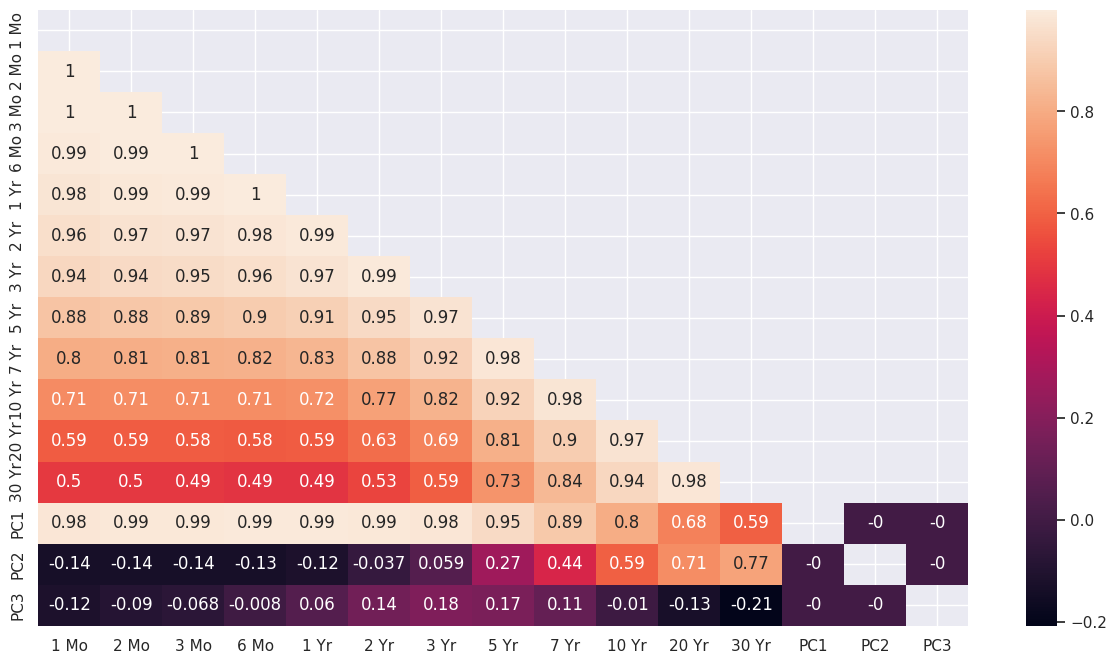

In [115]:
pc3_time.columns = ["PC1", "PC2", "PC3"]

corr_data = pd.concat([US_bond_data.iloc[:, 1:], pc3_time], axis = 1).corr().round(3)
mask_upper = np.triu(corr_data)
sns.heatmap(corr_data, annot = True, mask = mask_upper)
plt.savefig("Figure_3.png")

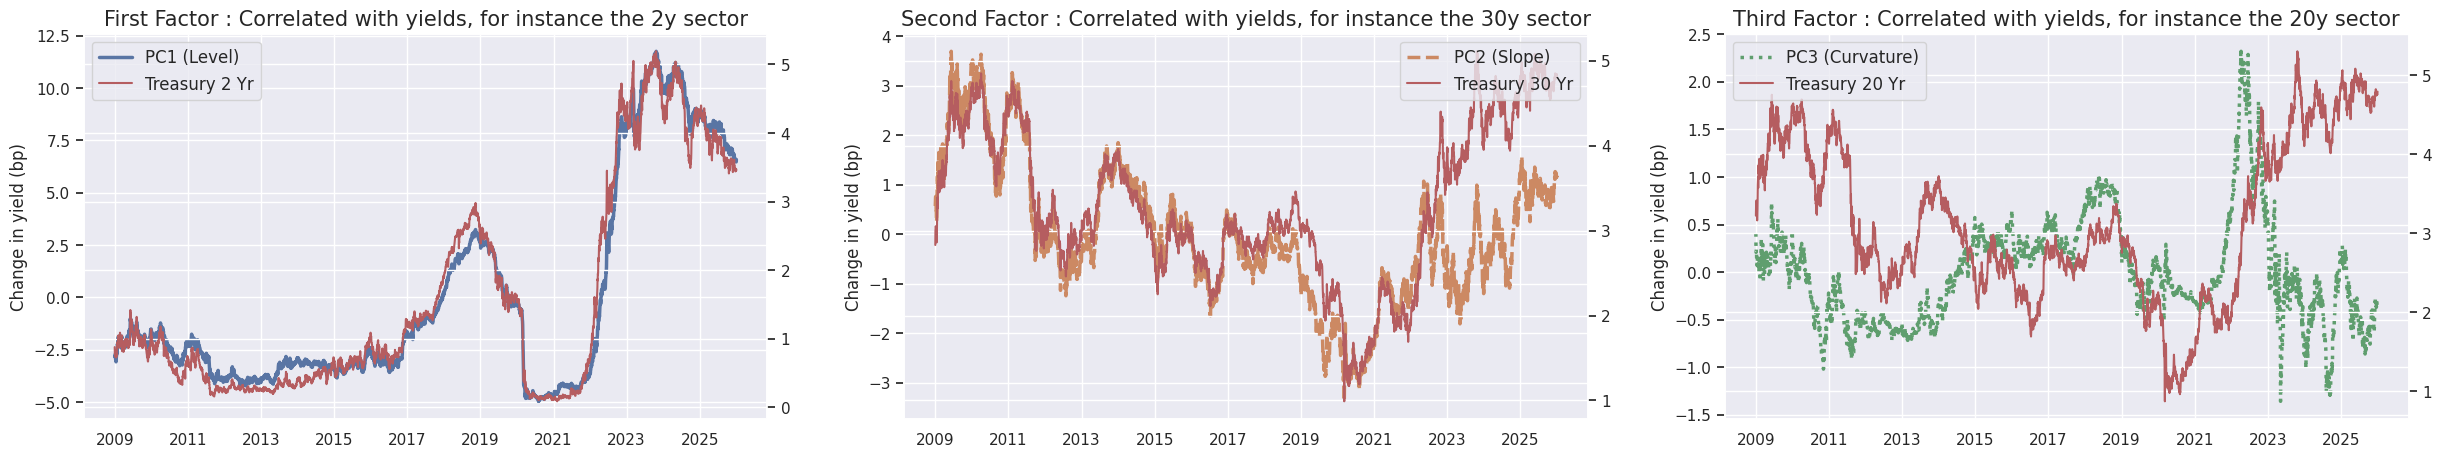

In [116]:
fig, axes = plt.subplots(1, 3, figsize=(30,5))


sns.lineplot(data=pc_overtime.iloc[:, 0], linewidth=2.5, ax=axes[0], label='PC1 (Level)', color='#5975A4')
axes[0].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[0].set_title("First Factor : Correlated with yields, for instance the 2y sector", fontsize = 15)
axes[0].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
axes[0].get_legend().remove()

ax2 = axes[0].twinx()
ax2.plot(US_bond_data.iloc[:, 1:]["2 Yr"], color='#B55D60', label='Treasury 2 Yr')
lines, labels = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=12)


# PC2 VS Treasury 30 Yr
sns.lineplot(data=pc_overtime.iloc[:, 1],  linewidth=2.5, ax = axes[1], label='PC2 (Slope)', color='#CC8963', linestyle='--')
axes[1].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[1].set_title("Second Factor : Correlated with yields, for instance the 30y sector", fontsize = 15)
axes[1].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
axes[1].get_legend().remove()

ax2 = axes[1].twinx()
ax2.plot(US_bond_data.iloc[:, 1:]["30 Yr"], color='#B55D60', label='Treasury 30 Yr')
lines, labels = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=12)


# PC3 VS Treasury 20 Yr
sns.lineplot(data=pc_overtime.iloc[:, 2],  linewidth=2.5, ax = axes[2], label='PC3 (Curvature)', color='#5F9E6E', linestyle='dotted')
axes[2].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[2].set_title("Third Factor : Correlated with yields, for instance the 20y sector", fontsize = 15)
axes[2].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
axes[2].get_legend().remove()

ax2 = axes[2].twinx()
ax2.plot(US_bond_data.iloc[:, 1:]["20 Yr"], color='#B55D60', label='Treasury 20 Yr')
lines, labels = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=12)


# plt
plt.savefig("Figure_4.png")

### 4-4. PCA Analysis [HW]

In [117]:
import scipy

def PCA_solver(df, num_reconstruct):

    dataset = df.copy()

    # Fill in the code!
    # Step 1   : Compute mean-centered data matr
    mean_centered_dataset = dataset - dataset.mean(axis=0)
    # Step 2-1 : Compute Covariance matrix
    cov_matrix = np.dot(mean_centered_dataset.T, mean_centered_dataset)
    # Step 2-2 : Use the function scipy.linalg.eigh
    eigenvals, eigenvecs = scipy.linalg.eigh(cov_matrix)

    eigenvecs = eigenvecs[:, np.argsort(eigenvals)[::-1]]
    eigenvals = eigenvals[np.argsort(eigenvals)[::-1]]
    eigenvecs = eigenvecs[:, :num_reconstruct]

    return np.dot(eigenvecs.T, df.T).T, eigenvals, eigenvecs

In [118]:
scores, evals, evecs = PCA_solver(US_bond_data.iloc[:,1:], 3)

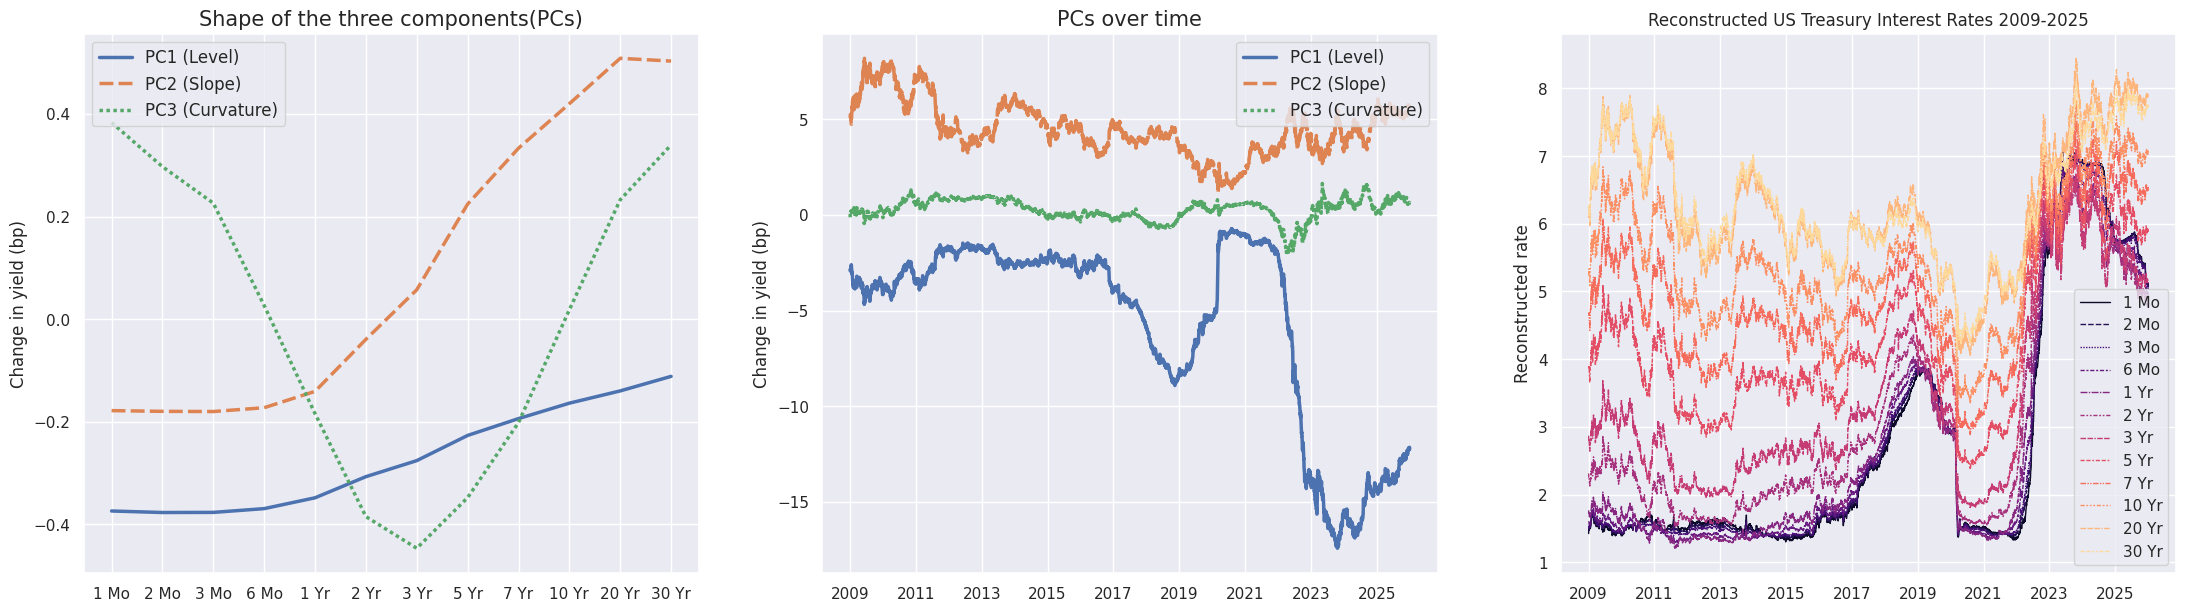

In [119]:
evecs = pd.DataFrame(evecs)
score = pd.DataFrame(scores)

fig, axes = plt.subplots(1, 3, figsize=(27,7))


# PCs over maturity
pc3_evecs = evecs.iloc[:, :3]
pc3_evecs.columns = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
sns.lineplot(data=pc3_evecs,  linewidth=2.5, ax = axes[0])
axes[0].set_title("Shape of the three components(PCs)", fontsize = 15)
axes[0].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[0].set_xticks([0,1,2,3,4,5,6,7,8,9,10,11],['1 Mo', '2 Mo', '3 Mo', '6 Mo', '1 Yr', '2 Yr', '3 Yr', '5 Yr', '7 Yr',  '10 Yr', '20 Yr', '30 Yr'])
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, loc='upper left', fontsize=12)


# PCs over time
pc3_score = score.iloc[:, :3]
pc3_score.columns = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
sns.lineplot(data=pc3_score,  linewidth=2.5, ax = axes[1])
axes[1].set_title("PCs over time", fontsize = 15)
axes[1].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[1].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
axes[1].legend(handles=handles, labels=labels, loc='upper right', fontsize=12)


# Reconstructed US Treasury interest
reconst = pd.DataFrame(np.dot(scores,evecs.T), index=US_bond_data.index, columns=US_bond_data.columns[1:])
reconst += US_bond_data.iloc[:, 1:].mean(axis = 0 )
sns.lineplot(data=reconst,  linewidth=1.0, palette = "magma")
axes[2].set_title("Reconstructed US Treasury Interest Rates 2009-2025", fontsize = 12)
axes[2].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
axes[2].set_ylabel("Reconstructed rate", fontsize = 12)


# plt
plt.savefig("Figure_5.png")
plt.show()

### 5. PCA applied to finance by using Korean DATA [HW]

point 1. Since Korean data has 6 columns, the number of PCs should not be set to 10 like the US data.  
point 2. The following graphs must be output as figures.

1.   Shape of the three components(PCs)
##### xticks : [0,1,2,3,4,5],['1 Yr', '3 Yr', '5 Yr',  '10 Yr', '20 Yr', '30 Yr']
2.   PCs over time
##### xticks : [0,500,1000,1500,2000,2500,3000],['2013','2015','2017','2019','2021','2023','2025']
3.   Reconstructed Korea Treasury Interest Rates 2013-2025
##### xticks : [0,500,1000,1500,2000,2500,3000],['2013','2015','2017','2019','2021','2023','2025']

In [120]:
KO_bond_data  = pd.read_csv('/KO_bond_data_26Spr.csv')

In [121]:
ko_scores, ko_evals, ko_evecs = PCA_solver(KO_bond_data.iloc[:, 1:], 3)

ko_evecs_df = pd.DataFrame(ko_evecs)
ko_score_df = pd.DataFrame(ko_scores)

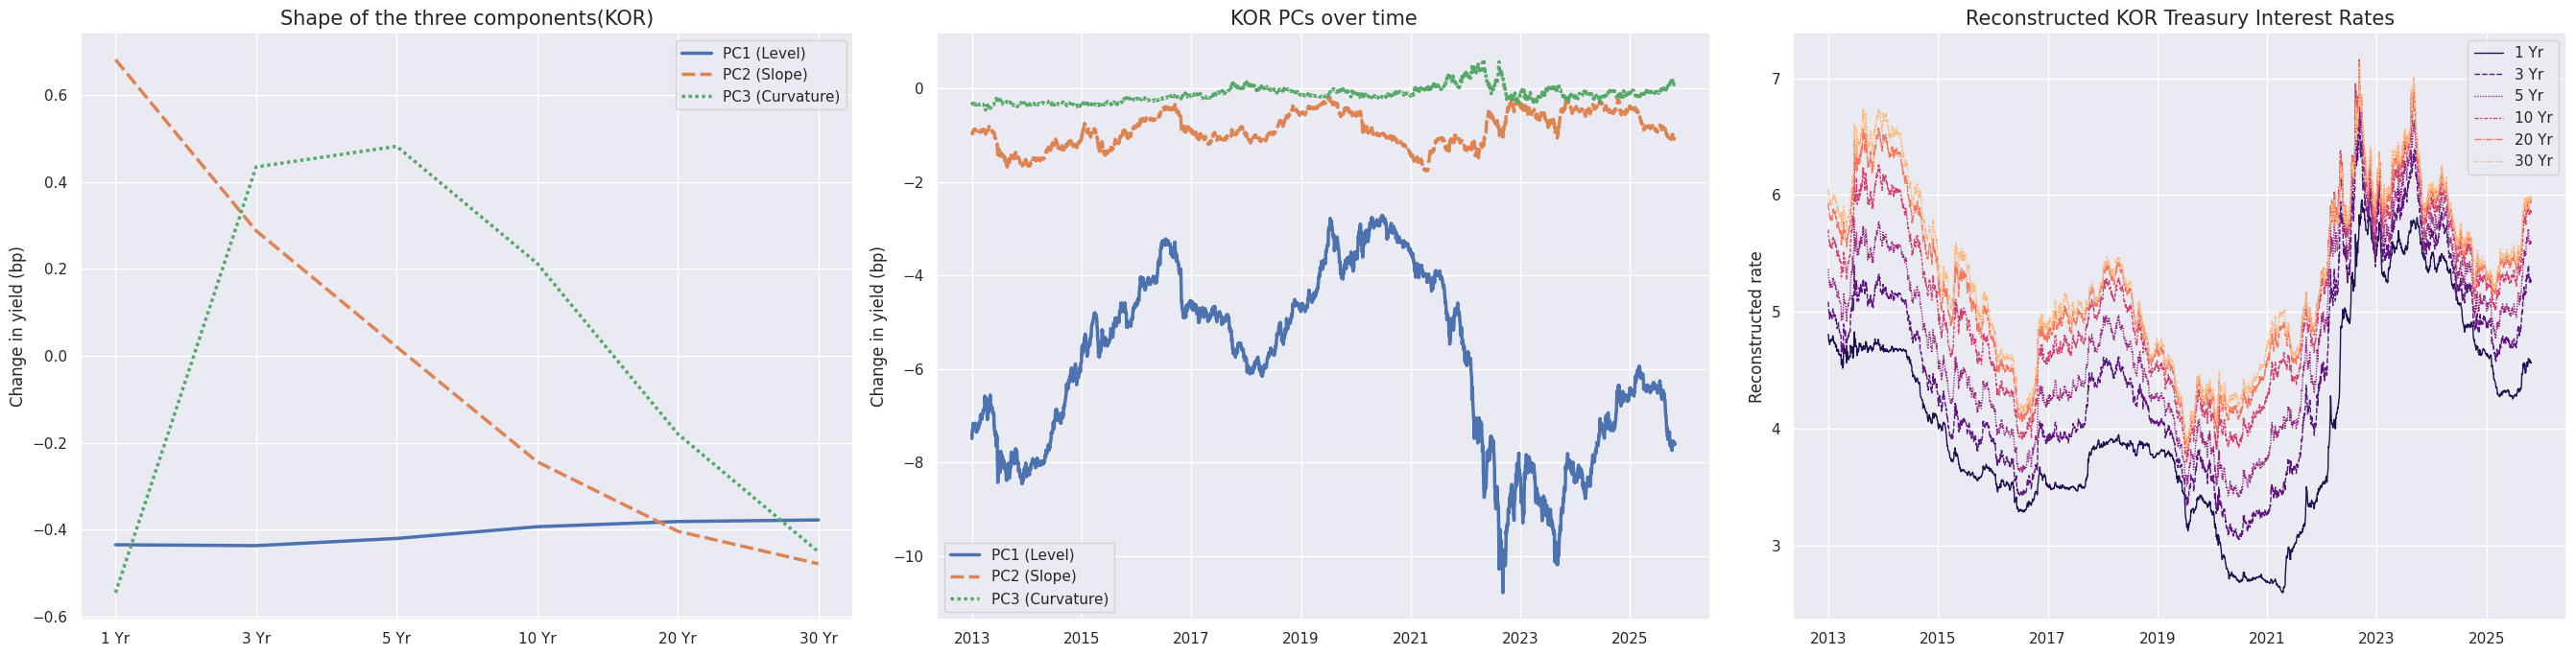

1, Individual Explained Variance Ratio (per PC)
[0.955 0.037 0.008 0.001 0.    0.   ]
2. Cumulative Explained Variance Ratio
[0.955 0.991 0.999 1.    1.    1.   ]


In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 3, figsize = (27,7))

# Shape of the three components
ko_evecs_df.columns = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
sns.lineplot(data = ko_evecs_df, linewidth = 2.5, ax = axes[0])
axes[0].set_title("Shape of the three components(KOR)", fontsize = 15)
axes[0].set_xticks([0,1,2,3,4,5])
axes[0].set_xticklabels(['1 Yr', '3 Yr', '5 Yr', '10 Yr', '20 Yr', '30 Yr'])
axes[0].set_ylabel("Change in yield (bp)")

# PCs over time
ko_score_df.columns = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']
sns.lineplot(data = ko_score_df, linewidth = 2.5, ax = axes[1])
axes[1].set_title("KOR PCs over time", fontsize = 15)
axes[1].set_xticks([0,500,1000,1500,2000,2500,3000])
axes[1].set_xticklabels(['2013', '2015', '2017', '2019', '2021', '2023', '2025'])
axes[1].set_ylabel("Change in yield (bp)")

# Reconstructed Korea Treasury Interest Rates 2013-2025
ko_reconst = pd.DataFrame(np.dot(ko_scores, ko_evecs.T), index = KO_bond_data.index, columns = KO_bond_data.columns[1:])
ko_reconst += KO_bond_data.iloc[:, 1:].mean(axis = 0)

sns.lineplot(data = ko_reconst, linewidth = 1.0, palette = "magma", ax = axes[2])
axes[2].set_title("Reconstructed KOR Treasury Interest Rates", fontsize = 15)
axes[2].set_xticks([0,500,1000,1500,2000,2500,3000])
axes[2].set_xticklabels(['2013', '2015', '2017', '2019', '2021', '2023', '2025'])
axes[2].set_ylabel("Reconstructed rate")

plt.savefig("Korean.png")
plt.tight_layout()
plt.show()

# Check PCA Explanatory Power (Expressed as Variance Ratio)
individual_ratio = ko_evals/np.sum(ko_evals)
cumulative_ratio = np.cumsum(individual_ratio)

print("1, Individual Explained Variance Ratio (per PC)")
print(individual_ratio.round(3))

print("2. Cumulative Explained Variance Ratio")
print(cumulative_ratio.round(3))



### 6. Market regime analysis via Clustering [HW]

- **K-Means clustering** is one of the most widely used unsupervised learning algorithms that partitions $N$ data points into $K$ clusters by minimizing the within-cluster sum of squares (WCSS).

- Given a dataset $\mathbf{X} = \{\mathbf{x}_1, \mathbf{x}_2, \dots, \mathbf{x}_N\} \in \mathbb{R}^d$, K-Means aims to find a set of $K$ cluster centroids $\{\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_K\}$ and assignments $\{c_1, \dots, c_N\}$ that minimize:

$$J = \sum_{i=1}^{N} \|\mathbf{x}_i - \boldsymbol{\mu}_{c_i}\|^2$$

- The algorithm iterates between two steps until convergence:
  - **Assignment step**: Assign each data point to its nearest centroid:
$$c_i = \arg\min_{k} \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$$
  - **Update step**: Recompute each centroid as the mean of its assigned points:
$$\boldsymbol{\mu}_k = \frac{1}{|S_k|}\sum_{\mathbf{x}_i \in S_k} \mathbf{x}_i$$

- In this homework, apply K-Means to the first three principal components (PC1, PC2, PC3) extracted from US bond yield data to identify distinct **market regimes**.
- You should include the following in your report:
  1. **PC1 vs PC2 scatter plot** colored by cluster
  2. **Regime over time** plot
  3. **Average yield curve** per regime

In [123]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Reload data
US_bond_data = pd.read_csv('/US_bond_data_26Spr.csv')

k_regimes =  3  # Choose the number of clusters

us_pc_shape, us_pc_overtime = PCA_analysis(US_bond_data, norm = True, n_pcs = 10)
us_pc_regime_data = us_pc_overtime.iloc[:, :3].copy()
us_pc_regime_data.columns = ["PC1", "PC2", "PC3"]

kmeans = KMeans(n_clusters=k_regimes, random_state=2026)
us_pc_regime_data["Regime"] = kmeans.fit_predict(us_pc_regime_data)

us_yield_curve_data = US_bond_data.iloc[:, 1:].copy()
us_yield_curve_data["Regime"] = us_pc_regime_data["Regime"].values

print(f"Number of regimes (k): {k_regimes}")
print(us_pc_regime_data["Regime"].value_counts().sort_index().rename(index=lambda x: f"Regime {x}"))

explained variance ratio : [0.90992768 0.98578555 0.99786658]
Number of regimes (k): 3
Regime
Regime 0    2657
Regime 1     825
Regime 2     769
Name: count, dtype: int64


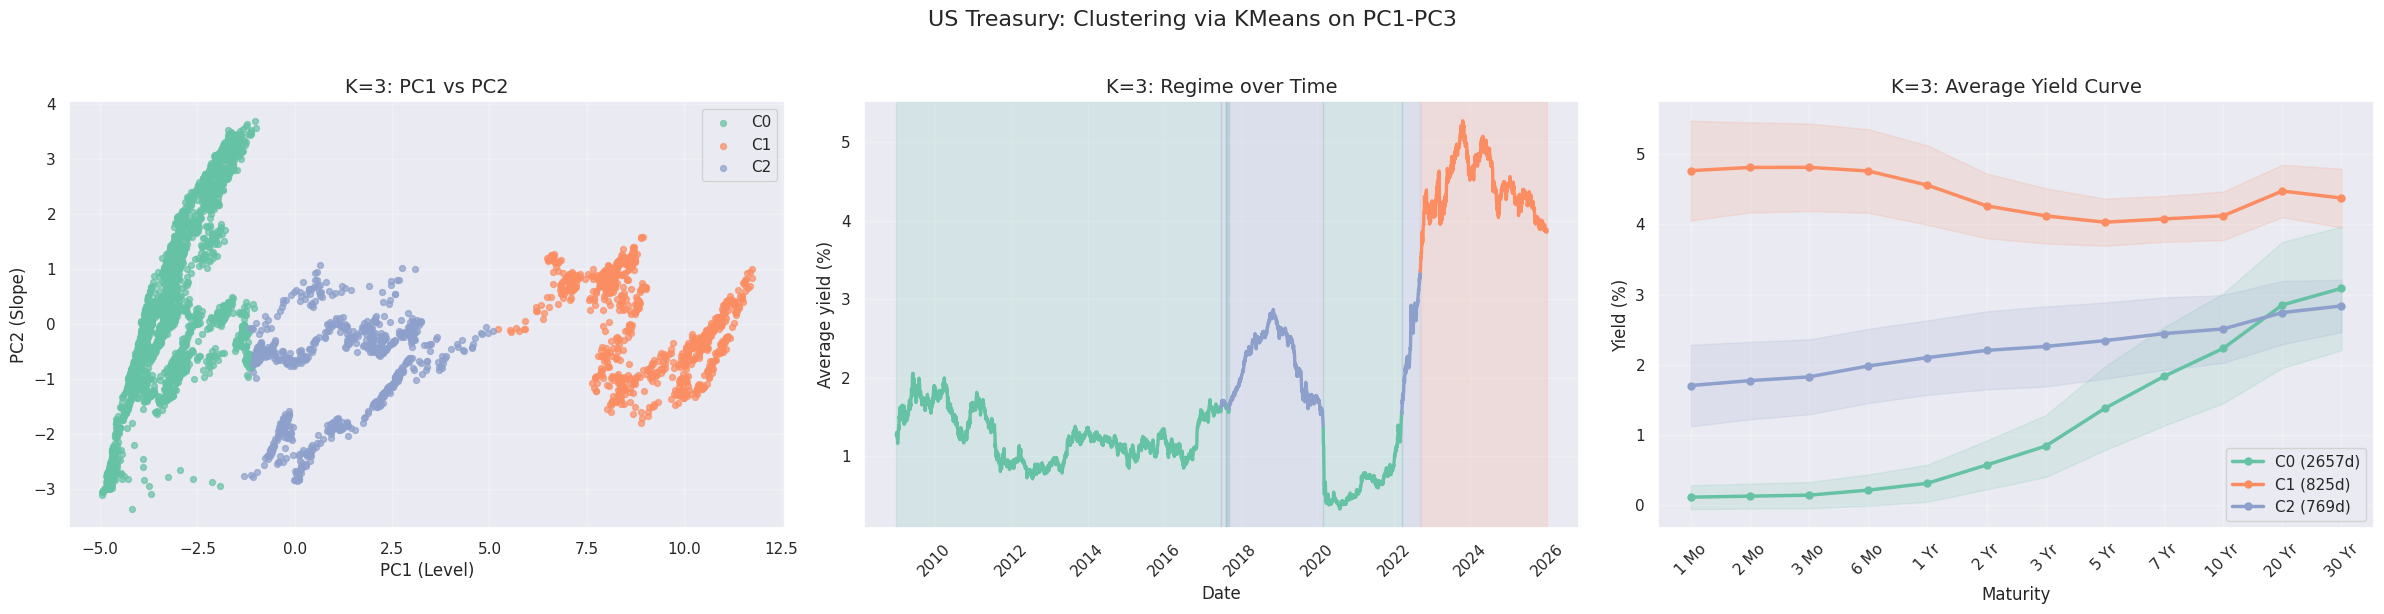

In [124]:
regime_palette = sns.color_palette("Set2", n_colors=k_regimes)

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

# ---- (1) PC1 vs PC2 scatter ----
ax = axes[0]
for regime_idx in range(k_regimes):
    regime_points = us_pc_regime_data[us_pc_regime_data["Regime"] == regime_idx]
    ax.scatter(regime_points["PC1"], regime_points["PC2"],
               color=regime_palette[regime_idx], s=18, alpha=0.7, label=f"C{regime_idx}")
ax.set_title(f"K={k_regimes}: PC1 vs PC2", fontsize=14)
ax.set_xlabel("PC1 (Level)")
ax.set_ylabel("PC2 (Slope)")
ax.legend()
ax.grid(alpha=0.25)

# ---- (2) Regime over time ----
ax = axes[1]
us_regime_ts = pd.DataFrame({
    "Date": pd.to_datetime(US_bond_data.iloc[:, 0]),
    "Average Rate": US_bond_data.iloc[:, 1:].mean(axis=1),
    "Regime": us_pc_regime_data["Regime"].values
}).sort_values("Date").reset_index(drop=True)

regime_blocks = us_regime_ts.groupby((us_regime_ts["Regime"] != us_regime_ts["Regime"].shift()).cumsum())

ax.plot(us_regime_ts["Date"], us_regime_ts["Average Rate"], color="dimgray", linewidth=1.2, alpha=0.45)
for _, block in regime_blocks:
    regime_idx = int(block["Regime"].iloc[0])
    regime_color = regime_palette[regime_idx]
    start_idx = max(block.index[0] - 1, 0)
    end_idx = block.index[-1]
    segment = us_regime_ts.iloc[start_idx:end_idx + 1]
    ax.axvspan(block["Date"].iloc[0], block["Date"].iloc[-1], color=regime_color, alpha=0.16)
    ax.plot(segment["Date"], segment["Average Rate"], color=regime_color, linewidth=2.4)

ax.set_title(f"K={k_regimes}: Regime over Time", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Average yield (%)")
ax.grid(alpha=0.25)
ax.tick_params(axis='x', rotation=45)

# ---- (3) Average Yield Curve ----
ax = axes[2]
us_maturity_labels = US_bond_data.columns[1:]
x = np.arange(len(us_maturity_labels))
for regime_idx in range(k_regimes):
    regime_curves = us_yield_curve_data[us_yield_curve_data["Regime"] == regime_idx].drop(columns="Regime")
    n = len(regime_curves)
    mean_curve = regime_curves.mean(axis=0).values
    std_curve = regime_curves.std(axis=0).values
    ax.plot(x, mean_curve, color=regime_palette[regime_idx], linewidth=2.5, marker='o', markersize=5,
            label=f"C{regime_idx} ({n}d)")
    ax.fill_between(x, mean_curve - std_curve, mean_curve + std_curve,
                     color=regime_palette[regime_idx], alpha=0.15)

ax.set_title(f"K={k_regimes}: Average Yield Curve", fontsize=14)
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield (%)")
ax.set_xticks(x)
ax.set_xticklabels(us_maturity_labels, rotation=45)
ax.legend()
ax.grid(alpha=0.25)

fig.suptitle("US Treasury: Clustering via KMeans on PC1-PC3", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### [Advanced, Optional] 7. Autoencoder

![image.png](https://drive.google.com/uc?id=17CIHo-9f0bcOhWBGnIcCkqdr_8b07xDP)

Source :KB Kim, *YT Hwang*, DC Lim, SH Kim, JH Lee, and *YJ Lee*, (2022), Diagnosis and Prescription for Household Financial Health via Risk Information embedded Hierarchical AutoEncoder and Its Post-hoc Analysis, working paper

- An autoencoder (AE) is a dimension reduction technique based on artificial neural networks and is often referred to as a deep learning version of principal component analysis (PCA), one of the most popular dimension reduction methods. While PCA is only able to capture linear dependence structures within data, AE is known to capture complex non-linear dependencies well.
- The AE is composed of an encoder function $f_{ENC}: R^d→R^k$ and a decoder function $f_{DEC}: R^d→R^k$. The encoder function $f_{ENC}$ is a mapping from high-dimensional data $Χ∈R^{(N×d)}$ with N samples and d features to corresponding embeddings $Z∈R^{(N×k)}$ in a k-dimensional latent space with $k≪d$. The decoder function $f_{DEC}$ is a mapping from embeddings $Z∈R^{(N×k)}$ to the original data $Χ∈R^{(N×d)}$. AE is trained to minimize the following reconstruction loss:

$$l_{AE}= ∥Χ-f_{DEC} (f_{ENC} (Χ)) ∥_F^2$$

where $∥∙∥_F^2$ is the Frobenius norm.

### 7-1. Linear Autoencoder

In [125]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch.backends.cudnn as cudnn
from tqdm import tqdm
import random
from sklearn.preprocessing import StandardScaler

seed = 2022
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
cudnn.benchmark = False
cudnn.deterministic = True

#### Simple dataloaer

In [126]:
class bondDataloader(Dataset):
    def __init__(self, csvdata):
        self.dataset = csvdata.values

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        return torch.tensor(self.dataset[idx], dtype = torch.float32)

#### Hyperparameter

In [127]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
batch_size = 64
learning_rate = 1e-3
epochs = 10

In [128]:
US_bond_data = US_bond_data.iloc[:, 1:] - US_bond_data.iloc[:, 1:].mean(axis=0)
scaler = StandardScaler()
bond_data = pd.DataFrame(scaler.fit_transform(US_bond_data), columns=US_bond_data.columns)

train_dataset = bondDataloader(bond_data)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,shuffle=True)
test_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,shuffle=False)

In [129]:
class LinearAE(nn.Module):
    def __init__(self):
        super(LinearAE, self).__init__()

        self.encoder = nn.Sequential(
                nn.Linear(12, 10, bias = False),
        )

        self.decoder =  nn.Sequential(
               nn.Linear(10, 12, bias = False),
        )


    def forward(self, bond_input):
        encoder_output = self.encoder(bond_input)
        decoder_output = self.decoder(encoder_output)
        return encoder_output, decoder_output

#### Model

In [130]:
autoencoder = LinearAE()
autoencoder = autoencoder.to(device)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr = learning_rate)
criterion = nn.MSELoss()

In [131]:
encoder_weights = autoencoder.encoder[0].weight.data.cpu().numpy()
encoder_weights_df = pd.DataFrame(encoder_weights).T

#### Learning

In [132]:
def train_step(batch_item):
    bond_batch_x = batch_item.to(device)
    bond_batch_y = batch_item.to(device)

    autoencoder.train()
    optimizer.zero_grad()

    encoder, decoder = autoencoder(bond_batch_x)
    loss = criterion(decoder, bond_batch_y)

    loss.backward()
    optimizer.step()

    return loss

In [133]:
for epoch in range(epochs):
    total_loss = 0

    tqdm_dataset = tqdm(enumerate(train_dataloader))

    for batch, batch_item in tqdm_dataset:
        batch_loss = train_step(batch_item)
        total_loss += batch_loss

        tqdm_dataset.set_postfix({
                'Epoch': epoch + 1,
                'Loss': '{:06f}'.format(batch_loss.item()),
                'Mean Loss' : '{:06f}'.format(total_loss/(batch+1))
            })


67it [00:00, 307.16it/s, Epoch=1, Loss=0.401494, Mean Loss=0.785027]
67it [00:00, 308.04it/s, Epoch=2, Loss=0.083313, Mean Loss=0.237015]
67it [00:00, 315.83it/s, Epoch=3, Loss=0.040933, Mean Loss=0.062128]
67it [00:00, 300.06it/s, Epoch=4, Loss=0.021279, Mean Loss=0.028681]
67it [00:00, 318.76it/s, Epoch=5, Loss=0.012884, Mean Loss=0.018178]
67it [00:00, 309.43it/s, Epoch=6, Loss=0.015142, Mean Loss=0.014214]
67it [00:00, 304.62it/s, Epoch=7, Loss=0.007995, Mean Loss=0.012173]
67it [00:00, 307.05it/s, Epoch=8, Loss=0.010713, Mean Loss=0.010813]
67it [00:00, 287.30it/s, Epoch=9, Loss=0.007610, Mean Loss=0.009578]
67it [00:00, 292.05it/s, Epoch=10, Loss=0.005988, Mean Loss=0.008422]


In [134]:
def predict(dataset):
    autoencoder.eval()
    tqdm_dataset = tqdm(enumerate(dataset))
    results = []
    for batch, batch_item in tqdm_dataset:
        bond_batch_x = batch_item.to(device)

        with torch.no_grad():
            encoder, decoder = autoencoder(bond_batch_x)

        results.extend(encoder.cpu().numpy())

    return results

preds = predict(test_dataloader)

67it [00:00, 1295.71it/s]


In [135]:
encoder_weights = autoencoder.encoder[0].weight.data.cpu().numpy()
encoder_weights_df = pd.DataFrame(encoder_weights).T

AE_PCs = pd.DataFrame(preds)

In [136]:
# Data setting
pc3_time.columns = ['PC1 (Level)', 'PC2 (Slope)', 'PC3 (Curvature)']

AE_data = AE_PCs.iloc[:, :3]
AE_data.columns = ["AE_PC1" ,"AE_PC2", "AE_PC3"] # for ordering
AE_data = AE_data[["AE_PC1", "AE_PC2", "AE_PC3"]]

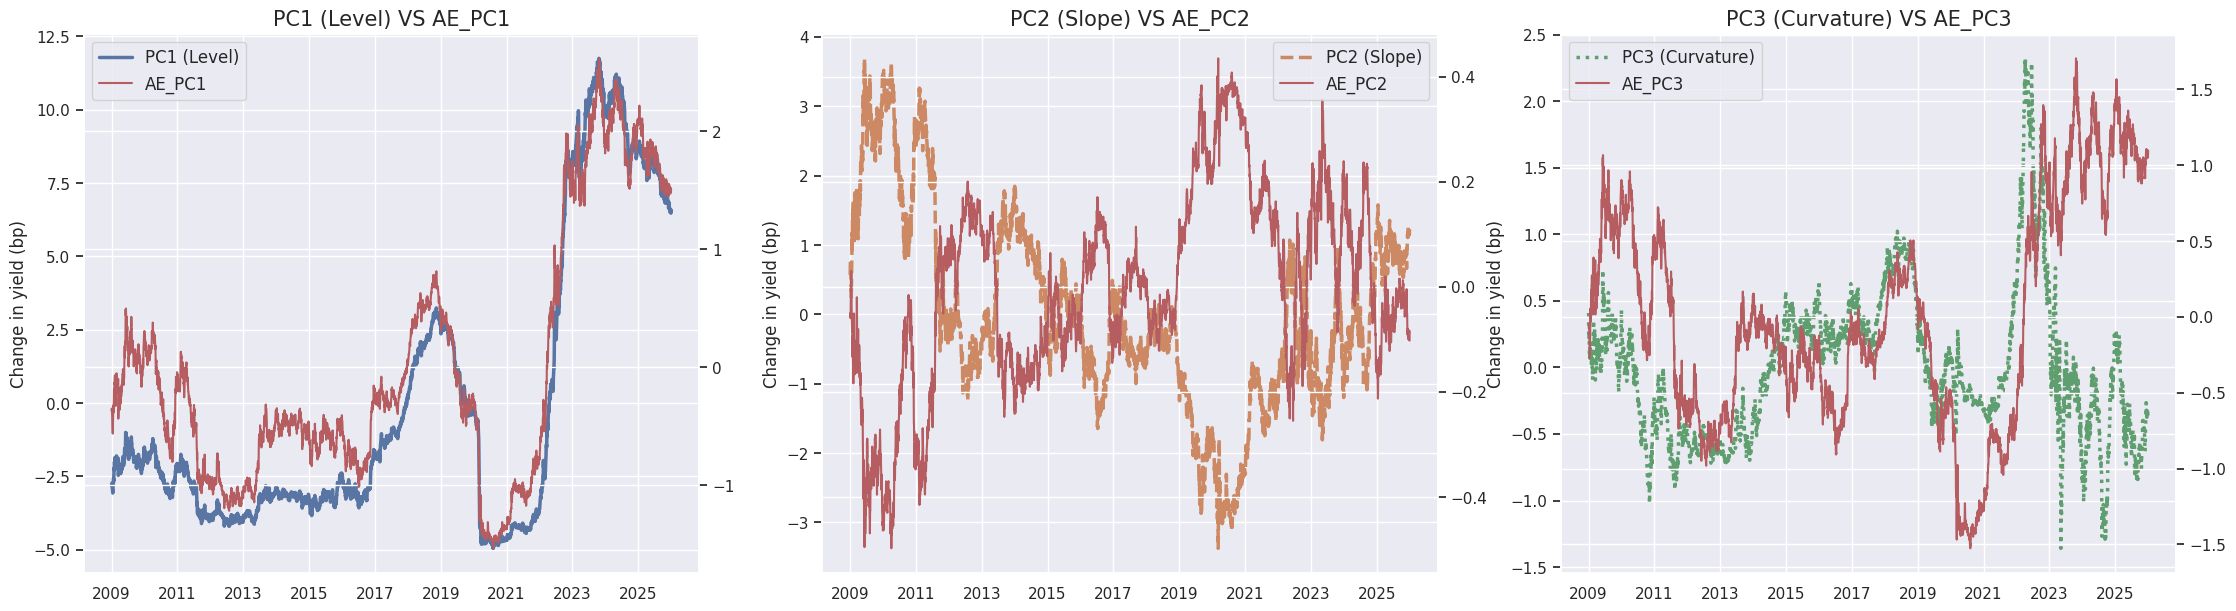

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(27,7))

# PC1 VS AE_PC1
sns.lineplot(data=pc3_time['PC1 (Level)'], linewidth=2.5, ax=axes[0], label='PC1 (Level)', color='#5975A4')
axes[0].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[0].set_title("PC1 (Level) VS AE_PC1", fontsize = 15)
axes[0].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
axes[0].get_legend().remove()

ax2 = axes[0].twinx()
ax2.plot(AE_data["AE_PC1"], color='#B55D60', label='AE_PC1')
lines, labels = axes[0].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=12)


# PC2 VS AE_PC2
sns.lineplot(data=pc3_time['PC2 (Slope)'], linewidth=2.5, ax=axes[1], label='PC2 (Slope)', color='#CC8963', linestyle='--')
axes[1].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[1].set_title("PC2 (Slope) VS AE_PC2", fontsize = 15)
axes[1].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
axes[1].get_legend().remove()

ax2 = axes[1].twinx()
ax2.plot(AE_data["AE_PC2"], color='#B55D60', label='AE_PC2')
lines, labels = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', fontsize=12)


# PC3 VS AE_PC3
sns.lineplot(data=pc3_time['PC3 (Curvature)'], linewidth=2.5, ax=axes[2], label='PC3 (Curvature)', color='#5F9E6E', linestyle='dotted')
axes[2].set_ylabel("Change in yield (bp)", fontsize = 12)
axes[2].set_title("PC3 (Curvature) VS AE_PC3", fontsize = 15)
axes[2].set_xticks([0,500,1000,1500,2000,2500,3000,3500,4000],['2009','2011','2013','2015','2017','2019','2021','2023','2025'])
axes[2].get_legend().remove()

ax2 = axes[2].twinx()
ax2.plot(AE_data["AE_PC3"], color='#B55D60', label='AE_PC3')
lines, labels = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=12)


# plt
plt.savefig("Figure_6.png")
plt.show()

In [138]:
pc3_time.columns = ["PC1", "PC2", "PC3"]
AE_PCA_corr = pd.concat([pc3_time, AE_data], axis = 1).corr().round(3)
AE_PCA_corr

,PC1,PC2,PC3,AE_PC1,AE_PC2,AE_PC3
PC1,1.000,-0.000,-0.000,0.975,0.069,0.814
PC2,-0.000,1.000,-0.000,0.202,-0.960,0.569
PC3,-0.000,-0.000,1.000,0.081,-0.240,0.114
AE_PC1,0.975,0.202,0.081,1.000,-0.148,0.919
AE_PC2,0.069,-0.960,-0.240,-0.148,1.000,-0.517
AE_PC3,0.814,0.569,0.114,0.919,-0.517,1.000
